In [14]:
import os
import random
from datetime import datetime

from src.utils import io
from src.dataload.grouped_pattern import GroupedPatternDataset
from src.train.trainer import set_seed
from src.models.RESURF_MISRGRU import MISRGRU
from src.train.trainer import init_model_weights, build_optimizer, build_scheduler, LossBundle
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt



In [15]:
from src.dataload.sampler import FixedPatternBatchSampler


In [16]:
# Extract settings from the config file
config_path = "configs/training.json"
config_dict = io.load_json(config_path)
conf_data = config_dict["data"]
conf_sampler = config_dict["sampler"]
conf_training = config_dict["training"]

In [17]:
# Create a list of folders/paths to the image files 
input_folders = io.find_setting_subfolders(conf_data["data_root"], conf_data["input_dir"], conf_data["setting_filter"])
target_folders = io.find_setting_subfolders(conf_data["data_root"], conf_data["target_dir"], conf_data["setting_filter"])

In [18]:
# create dataset
dataset_all = GroupedPatternDataset(
            input_paths=input_folders,
            target_paths=target_folders,
            input_token=conf_data["input_token"],
            target_token=conf_data["target_token"],
            setting_filter=conf_data["setting_filter"],
            snr_filter=conf_data["snr_filter"],
            pair_by_snr=conf_data["pair_by_snr"],
            num_frames=conf_data["num_frames"],
            )
# get all the PIDs inside the dataset
# all_pattern_ids = list(dataset_all.pattern_to_indices)


In [19]:
# Split dataset for training and validation
dataset_training, dataset_validation, train_pids, val_pids = dataset_all.train_val_split(
    split_ratio=conf_training["split_ratio"],
    seed=conf_training["seed"],
)
if dataset_training.__len__() == 0 or dataset_validation.__len__() == 0:
    raise RuntimeError("Train/val split produced an empty dataset. Check filters / split_ratio.")


In [20]:
print("Dataset summary:", dataset_all.summary())
print("Train summary:", getattr(dataset_training, "summary", lambda: {"num_samples": len(dataset_training)})())
print("Val summary:", getattr(dataset_validation, "summary", lambda: {"num_samples": len(dataset_validation)})())

Dataset summary: {'num_samples': 2000, 'num_patterns': 200, 'min_samples_per_pattern': 10, 'max_samples_per_pattern': 10}
Train summary: {'num_samples': 1400, 'num_patterns': 140, 'min_samples_per_pattern': 10, 'max_samples_per_pattern': 10}
Val summary: {'num_samples': 600, 'num_patterns': 60, 'min_samples_per_pattern': 10, 'max_samples_per_pattern': 10}


In [21]:
# settings for training
config_model = io.load_json(conf_training["model_config_path"])
config_model = config_model[conf_training["model_type"]]
model = MISRGRU(config = config_model) #cnn.MISRGRU(config=config["network"])

model_init = conf_training["weights_init"]
init_model_weights(model, model_init )


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move the model to the specified device
model.to(device)

optimizer = build_optimizer(model, conf_training)
scheduler = build_scheduler(optimizer, conf_training)


In [23]:
loss_bundle = LossBundle(config_dict, device=device)
# output folder
out_folder = conf_training.get("checkpoints_dir", "checkpoints")
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
out_folder_stamped = os.path.join(out_folder, f"Model_{timestamp}")
os.makedirs(out_folder_stamped, exist_ok=True)

In [24]:
# dataloaders
batch_size = int(conf_training.get("batch_size", 10))
min_patterns = int(conf_training.get("min_patterns", 2))
max_patterns = int(conf_training.get("max_patterns", 4))
pin_memory = bool(conf_training.get("pin_memory", True))
num_workers = int(conf_training.get("num_workers", 0))

In [25]:
eval_sampler = FixedPatternBatchSampler(
    dataset_validation, batch_size=batch_size, min_patterns=min_patterns, max_patterns=max_patterns,
    shuffle_each_epoch=False, seed=conf_training.get("seed", 42),
)
eval_loader = DataLoader(dataset_validation, batch_sampler=eval_sampler, num_workers=num_workers, pin_memory=pin_memory)

# training loop
set_seed(conf_training.get("seed", 42))

epochs = 50 #int(conf_training.get("epochs", 200))
patience = int(conf_training.get("patience", 20))
best_val = float("inf")
counter = 0

train_hist, val_hist = [], []

Epoch 0 [train]: 91it [00:43,  2.10it/s]                        
Epoch 0 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.19it/s]


Epoch 0/50 | train=2.7731e+01 | val=1.6672e+01 | lr=1.000e-03 | w1=0.007 w2=1.993


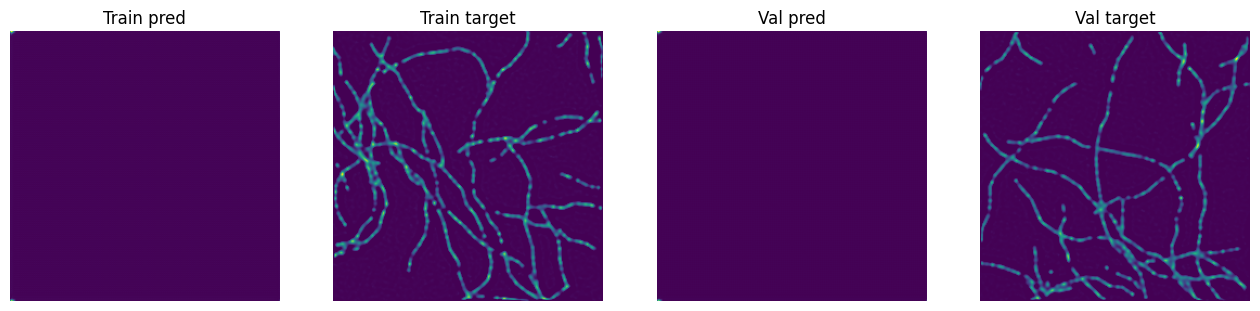

Epoch 1 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.05it/s]


Epoch 1/50 | train=1.6860e+01 | val=1.6477e+01 | lr=1.000e-03 | w1=0.007 w2=1.993


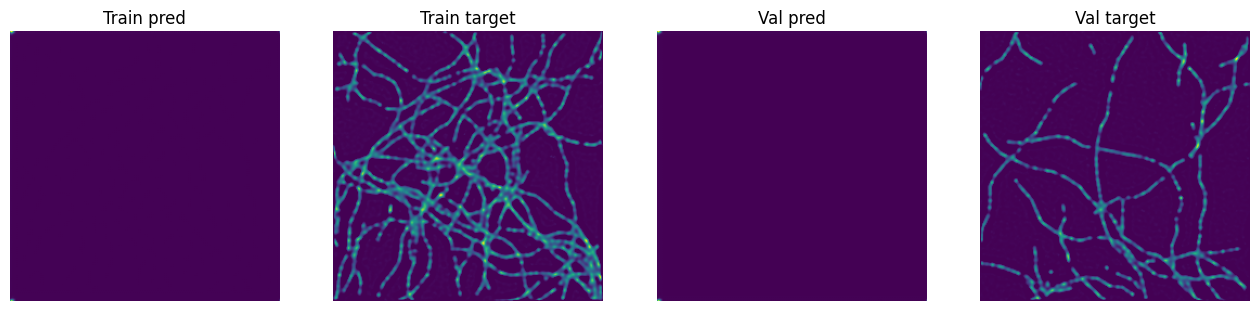

Epoch 2 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.07it/s]


Epoch 2/50 | train=1.6592e+01 | val=1.5519e+01 | lr=1.000e-03 | w1=0.007 w2=1.993


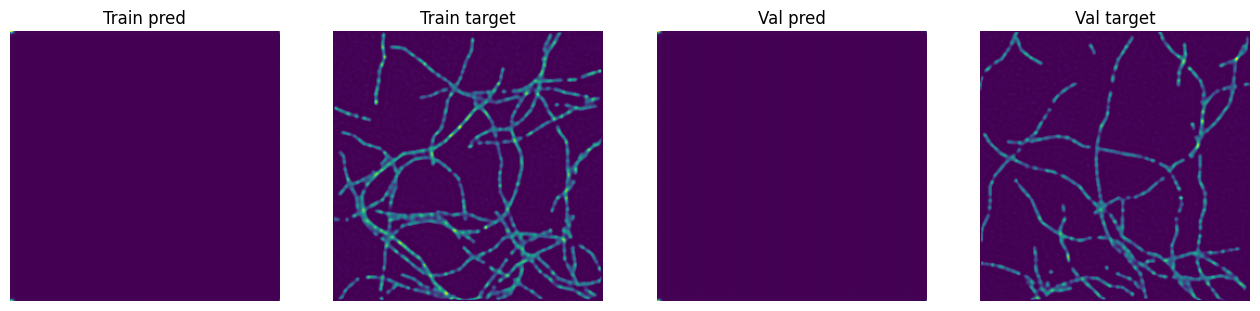

Epoch 3 [train]: 92it [00:44,  2.07it/s]                        
Epoch 3 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.05it/s]


Epoch 3/50 | train=1.6296e+01 | val=1.5639e+01 | lr=1.000e-03 | w1=0.007 w2=1.993


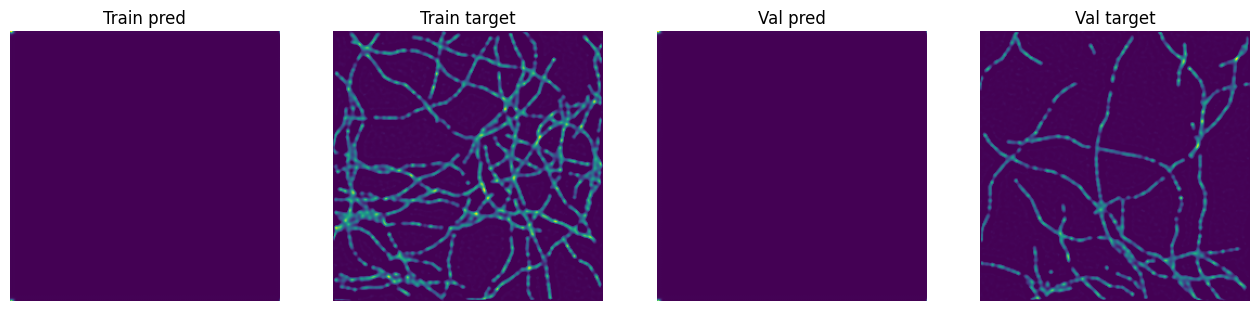

Epoch 4 [train]: 87it [00:41,  2.11it/s]                        
Epoch 4 [val]: 100%|██████████| 36/36 [00:04<00:00,  8.99it/s]


Epoch 4/50 | train=1.6261e+01 | val=1.5530e+01 | lr=1.000e-03 | w1=0.007 w2=1.993


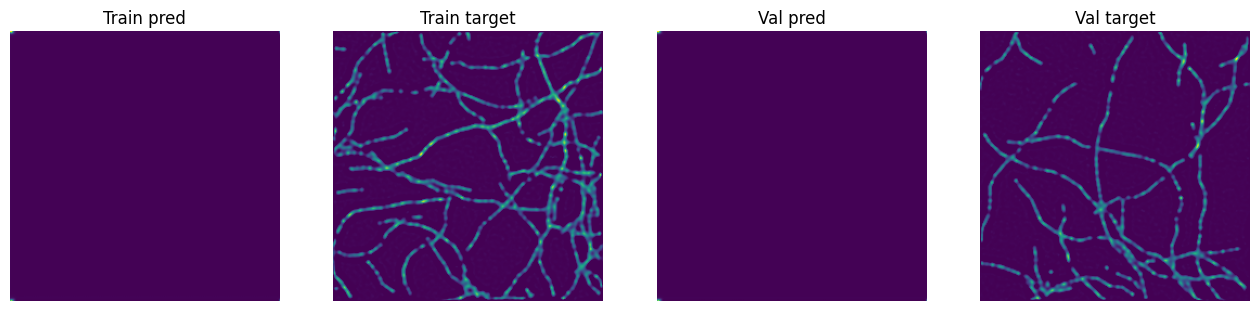

Epoch 5 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.01it/s]


Epoch 5/50 | train=1.5219e+01 | val=1.4640e+01 | lr=1.000e-03 | w1=0.136 w2=1.864


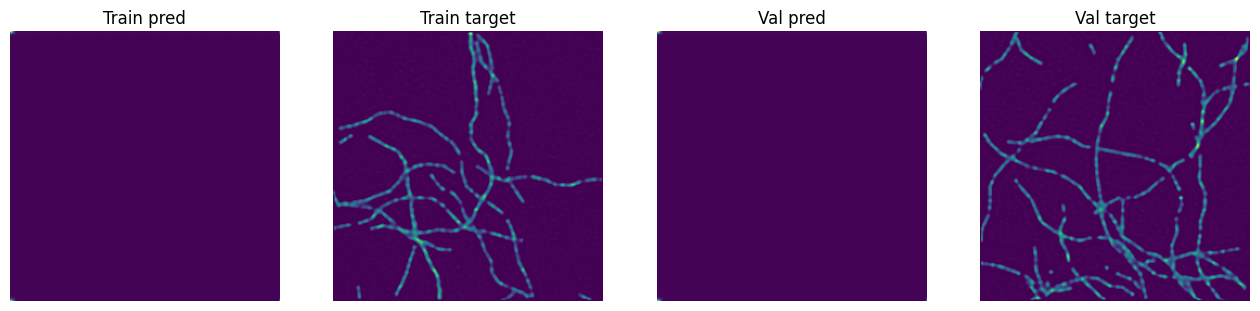

Epoch 6 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.01it/s]


Epoch 6/50 | train=1.5218e+01 | val=1.4433e+01 | lr=1.000e-03 | w1=0.136 w2=1.864


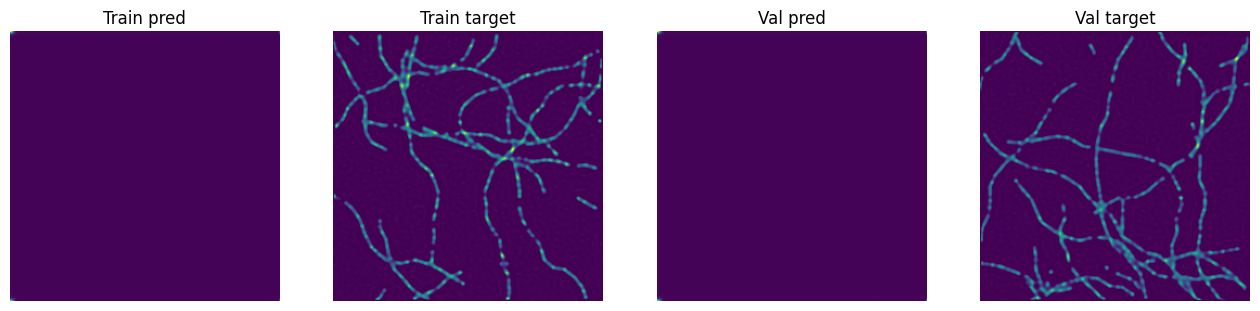

Epoch 7 [train]: 91it [00:43,  2.08it/s]                        
Epoch 7 [val]: 100%|██████████| 36/36 [00:03<00:00,  9.02it/s]


Epoch 7/50 | train=1.5109e+01 | val=1.4357e+01 | lr=1.000e-03 | w1=0.136 w2=1.864


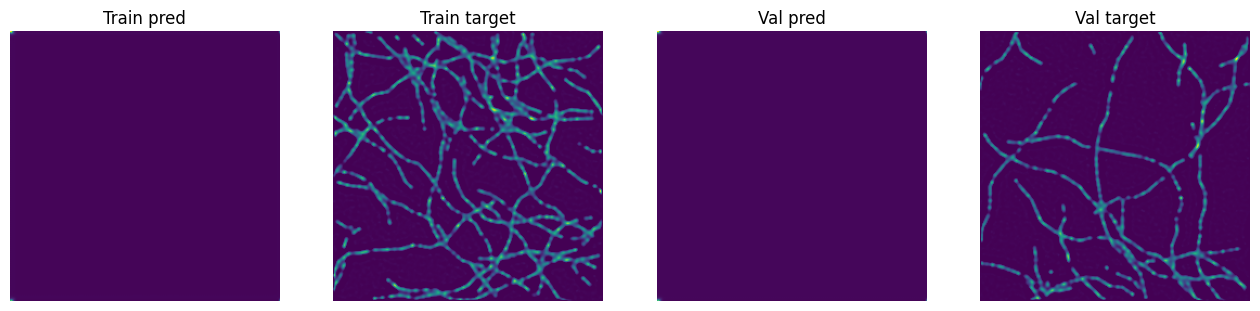

Epoch 8 [train]:   7%|▋         | 6/85 [00:03<00:50,  1.55it/s]


KeyboardInterrupt: 

In [26]:
for epoch in range(epochs):
    torch.cuda.empty_cache()

    train_sampler = FixedPatternBatchSampler(
        dataset_training, batch_size=batch_size, min_patterns=min_patterns, max_patterns=max_patterns,
        shuffle_each_epoch=True, seed=conf_training.get("seed", 42) + epoch,
    )
    train_loader = DataLoader(dataset_training, batch_sampler=train_sampler, num_workers=num_workers, pin_memory=pin_memory)

    # ---- train
    model.train()
    train_sum = 0.0
    last_pred = last_tgt = None

    for b_idx, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch} [train]")):
        x = batch["input"].to(device, non_blocking=True)
        y = batch["target"].to(device, non_blocking=True)

        # optional auto-weight update (only triggers when configured)
        loss_bundle.maybe_update_weights(model, x, y, epoch=epoch, b_idx=b_idx)

        optimizer.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_bundle(out, y)
        loss.backward()
        optimizer.step()

        train_sum += float(loss.detach().item())

        with torch.no_grad():
            last_pred = out[0].detach().cpu()
            last_tgt = y[0].detach().cpu()

        del x, y, out, loss

    avg_train = train_sum / max(1, len(train_loader))
    train_hist.append(avg_train)

    # ---- val
    model.eval()
    val_sum = 0.0
    last_pred_v = last_tgt_v = None

    with torch.no_grad():
        for batch in tqdm(eval_loader, desc=f"Epoch {epoch} [val]"):
            x = batch["input"].to(device, non_blocking=True)
            y = batch["target"].to(device, non_blocking=True)

            out = model(x)
            vloss = loss_bundle(out, y)

            val_sum += float(vloss.item())
            last_pred_v = out[0].detach().cpu()
            last_tgt_v = y[0].detach().cpu()

            del x, y, out, vloss

    avg_val = val_sum / max(1, len(eval_loader))
    val_hist.append(avg_val)

    # scheduler
    if scheduler is not None:
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(avg_val)
        else:
            scheduler.step()

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch}/{epochs} | train={avg_train:.4e} | val={avg_val:.4e} | lr={lr:.3e} | w1={float(loss_bundle.w1):.3f} w2={float(loss_bundle.w2):.3f}")

    # quick plot
    if last_pred is not None and last_pred_v is not None:
        plt.figure(figsize=(16, 4))
        plt.subplot(1, 4, 1); plt.imshow(last_pred.squeeze()); plt.title("Train pred"); plt.axis("off")
        plt.subplot(1, 4, 2); plt.imshow(last_tgt.squeeze()); plt.title("Train target"); plt.axis("off")
        plt.subplot(1, 4, 3); plt.imshow(last_pred_v.squeeze()); plt.title("Val pred"); plt.axis("off")
        plt.subplot(1, 4, 4); plt.imshow(last_tgt_v.squeeze()); plt.title("Val target"); plt.axis("off")
        plt.show()

    # checkpoint + early stopping
    if avg_val < best_val:
        best_val = avg_val
        counter = 0
        torch.save(model.state_dict(), os.path.join(out_folder_stamped, "best_model.pth"))
    else:
        counter += 1

    if counter >= patience and epoch > 10:
        print(f"Early stopping. Best val={best_val:.4e}")
        break

